# Trabajo Integrador Final - Python para la Ciencia de Datos

## Profesores: 
- *Acosta, Gabriel*
- *Benitez, Flavian Dante*

---

## Estudiantes:
- *Ayala, Santiago Tomás*
- *Zagaña, Torancio Alfonzo*
- *Zigaran, Lucas Natanael*

---

Análisis Clínico y Clasificación de Enfermedades Cardíacas utilizando Algoritmos de Machine Learning

In [76]:
# importaciones de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay


In [77]:
#Leemos el dataset y la cargamos en df
df = pd.read_csv('heart_disease_dataset.csv')

In [78]:
print("Forma del dataset:", df.shape)
# Cuenta cuántos ceros exactos hay en cada columna del dataset
(df == 0).sum()

Forma del dataset: (918, 12)


Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS         704
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak           368
ST_Slope            0
HeartDisease      410
dtype: int64

* **Detección de Anomalías:** El análisis exploratorio reveló valores en `0` (fisiológicamente imposibles en pacientes vivos) en las variables **Presión Arterial (`RestingBP`)** (1 caso) y **Colesterol (`Cholesterol`)** (172 casos).

In [79]:
print("\nTipos de datos:")
print(df.dtypes)



Tipos de datos:
Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object


In [80]:
df[df['RestingBP'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


In [81]:
df = df.drop(449)
# Verificamos que el índice 449 ha sido eliminado
print(449 in df.index)

False


# Hallazgo principal

Se detectó un **valor atípico e imposible** de **0 mm Hg** en la presión arterial en reposo (**RestingBP**) dentro de la fila **449**.

- Un valor de **0 mm Hg** es **biológicamente imposible** en un paciente vivo.
- Este dato se interpreta como un **error de digitalización** o un **registro médico perdido**.

## Impacto y resolución
- Al tratarse de un **caso aislado** dentro de los **918 registros** de `heart.csv`, se decidió **eliminar la fila completa** del flujo de datos.
- Esta acción evita que algoritmos sensibles a valores atípicos **sesguen sus métricas de distancia**, garantizando un entrenamiento más limpio y confiable para los modelos predictivos.

In [82]:
df[df['Cholesterol'] == 0]


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.4,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,0,0,Normal,120,N,0.5,Up,1
515,63,M,NAP,130,0,1,ST,160,N,3.0,Flat,0
518,48,M,NAP,102,0,1,ST,110,Y,1.0,Down,1
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1


# Observación importante

> Se detectaron **172 registros** con valor **0** en la variable **Cholesterol**.  
> En términos médicos, un valor de **0 mg/dl** de colesterol es **imposible** en una persona viva.

### ¿Qué significa esto?
- Estos valores representan **datos faltantes (missing data)**.
- Probablemente provienen de centros de recolección que **no realizaron la prueba analítica**.
- La fuerte asociación entre el valor 0 y la presencia de enfermedad cardíaca **no refleja una causa biológica**, sino un **sesgo de origen** en los datos.

### Interpretación
- El valor 0 debe tratarse como una **anomalía o dato inválido**.
- En el análisis, conviene **corregir, imputar o eliminar** estos registros según la estrategia elegida.

In [83]:
# Calculamos la mediana de los valores que SÍ son mayores a 0
mediana_colesterol = df[df['Cholesterol'] > 0]['Cholesterol'].median()
print(f"La mediana calculada es: {mediana_colesterol} mg/dl")

La mediana calculada es: 237.0 mg/dl


In [84]:
# Reemplazamos los ceros por esa mediana
df['Cholesterol'] = df['Cholesterol'].replace(0, mediana_colesterol)

In [85]:
# Corroboramos que ya no queden ceros
print(f"Ceros restantes en Cholesterol ===> {(df['Cholesterol'] == 0).sum()}")

Ceros restantes en Cholesterol ===> 0


# Tratamiento de Datos Faltantes en la Variable Cholesterol

Durante la etapa de análisis exploratorio, se identificaron **172 registros** con valor **0 mg/dl** en la columna **Cholesterol**, lo que equivale aproximadamente al **19% del dataset**.  
Este valor es **biológicamente imposible** en un paciente vivo, por lo que se interpretó como **dato faltante mal codificado**.

## ¿Qué se hizo?
En lugar de eliminar físicamente esas filas —lo que habría reducido de forma considerable la información clínica disponible— se aplicó una estrategia de **imputación por mediana** utilizando únicamente los valores válidos mayores a cero.

- **Mediana calculada:** **237 mg/dl**
- **Motivo de la elección:** mayor robustez frente a valores atípicos extremos

## Impacto de esta decisión
Esta técnica permitió:

- conservar la estructura del dataset,
- evitar el sesgo artificial generado por los ceros,
- mejorar la calidad de los datos para el entrenamiento de modelos de Machine Learning,
- incrementar la capacidad de generalización del modelo final.

> En resumen, el tratamiento aplicado convierte un error de registro en información útil, manteniendo la integridad del análisis clínico y predictivo.

In [86]:
# Convertimos las columnas de texto a columnas numéricas (0 y 1)
# transforma cada categoría de texto en columnas independientes de 0 (Falso) y 1 (Verdadero).
df_encoded = pd.get_dummies(
    df, 
    columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], 
    drop_first=True
)

## 2. Evitar la redundancia con `drop_first=True`

 **Objetivo:** prevenir la multicolinealidad (también llamada la “trampa de las variables ficticias”).

Cuando usamos `pd.get_dummies()`, cada categoría textual se convierte en una columna binaria.  
Por ejemplo, para la variable `Sex` se pueden crear:

- `Sex_F`
- `Sex_M`

Pero si dejamos todas estas columnas, el modelo puede detectar información repetida y perder estabilidad.

### ¿Qué hace `drop_first=True`?
- Elimina la primera categoría de cada variable.
- En este caso, se mantiene solo `Sex_M`.
- Si:
    - `Sex_M = 0` → la persona es mujer
    - `Sex_M = 1` → la persona es hombre

### ¿Por qué es importante?
- Evita columnas redundantes.
- Reduce el riesgo de multicolinealidad.
- Ayuda a que el modelo sea más limpio, estable y fácil de interpretar.

> En resumen: `drop_first=True` no elimina información útil, sino que evita que el modelo repita la misma idea con varias columnas.



In [87]:
df_encoded.info()

<class 'pandas.DataFrame'>
Index: 917 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                917 non-null    int64  
 1   RestingBP          917 non-null    int64  
 2   Cholesterol        917 non-null    int64  
 3   FastingBS          917 non-null    int64  
 4   MaxHR              917 non-null    int64  
 5   Oldpeak            917 non-null    float64
 6   HeartDisease       917 non-null    int64  
 7   Sex_M              917 non-null    bool   
 8   ChestPainType_ATA  917 non-null    bool   
 9   ChestPainType_NAP  917 non-null    bool   
 10  ChestPainType_TA   917 non-null    bool   
 11  RestingECG_Normal  917 non-null    bool   
 12  RestingECG_ST      917 non-null    bool   
 13  ExerciseAngina_Y   917 non-null    bool   
 14  ST_Slope_Flat      917 non-null    bool   
 15  ST_Slope_Up        917 non-null    bool   
dtypes: bool(9), float64(1), int64(6)
memory us

In [88]:
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [90]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [91]:
modelo_logistico = LogisticRegression(random_state=42)

In [92]:
modelo_logistico.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [93]:
print("--- PUNTAJES DE PRECISIÓN ---")
print(f"Exactitud en Entrenamiento (Train Score): {modelo_logistico.score(X_train_scaled, y_train):.4f}")
print(f"Exactitud en Prueba (Test Score):         {modelo_logistico.score(X_test_scaled, y_test):.4f}")

--- PUNTAJES DE PRECISIÓN ---
Exactitud en Entrenamiento (Train Score): 0.8581
Exactitud en Prueba (Test Score):         0.8750


In [94]:
y_pred = modelo_logistico.predict(X_test_scaled)

In [95]:
print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred))


--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.86      0.85      0.86        82
           1       0.88      0.89      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184



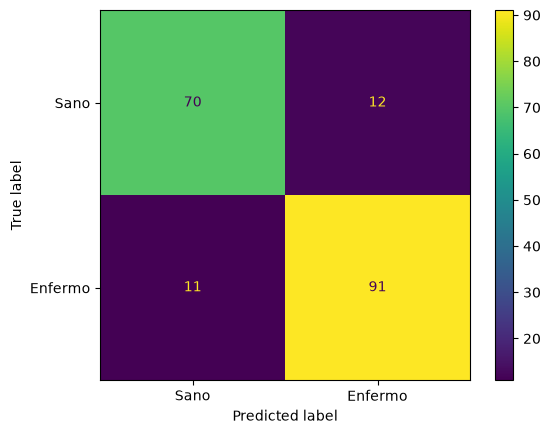

In [96]:
disp = ConfusionMatrixDisplay.from_estimator(
    modelo_logistico,
    X_test_scaled,
    y_test,
    display_labels=['Sano', 'Enfermo'],  
    ax=None  
)

In [97]:
pesos = modelo_logistico.coef_

df_pesos_2 = pd.DataFrame({
    "columna":X_train.columns,
    "pesos":pesos[0]
})

df_pesos_2.sort_values(by='pesos',ascending=False)

,columna,pesos
6,Sex_M,0.592430
3,FastingBS,0.538030
13,ST_Slope_Flat,0.498271
12,ExerciseAngina_Y,0.403281
5,Oldpeak,0.313280
0,Age,0.033365
2,Cholesterol,0.015533
1,RestingBP,0.004551
11,RestingECG_ST,-0.102688
10,RestingECG_Normal,-0.185437


In [98]:
X

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,True,False,False,True,True,False,False,True,False
914,68,144,193,1,141,3.4,True,False,False,False,True,False,False,True,False
915,57,130,131,0,115,1.2,True,False,False,False,True,False,True,True,False
916,57,130,236,0,174,0.0,False,True,False,False,False,False,False,True,False
